# Agent的高级用法-ToolStrategy
## 结构化输出方式：schema参数
### pydantic类型

In [2]:
import os
from dotenv import load_dotenv
from langchain_core.tools import tool

from langchain.agents.structured_output import AutoStrategy,ToolStrategy 
from langchain_core.messages import SystemMessage
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from rich import print as rprint

load_dotenv(override=True)
ARK_API_KEY = os.getenv("ARK_API_KEY")
ARK_MODEL_NAME = os.getenv("ARK_MODEL_NAME")
ARK_BASE_URL = os.getenv("ARK_BASE_URL")
model = ChatOpenAI(
    model= ARK_MODEL_NAME,
    api_key= ARK_API_KEY,
    base_url= ARK_BASE_URL
)
#使用pydantic结构化方法进行定义

class ContraactInfo(BaseModel):
    '''用户联系方式'''
    name : str = Field(description="用户姓名")
    email : str = Field(description="用户邮箱")
    phone : str = Field(description="用户电话")


agent = create_agent(
    model = model, 
    response_format= ToolStrategy(schema=ContraactInfo)
)

#调用
response = agent.invoke({
    "messages": [
        "请以客服『张三』的身份回复我，邮箱 zhangsan@example.com，电话 138-0000-1234"
    ]
})

rprint(response)


{
    'messages': [
        HumanMessage(
            content='请以客服『张三』的身份回复我，邮箱 zhangsan@example.com，电话 138-0000-1234',
            additional_kwargs={},
            response_metadata={},
            id='c4563aaa-67d2-4593-b382-e904b2ea8569'
        ),
        AIMessage(
            content='好的，我将以客服『张三』的身份为您服务，并登记以下联系方式：',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 169,
                    'prompt_tokens': 224,
                    'total_tokens': 393,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 115,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-5-3-flash-260828',
                'system_fingerprint': None,
                'id': '02179017216630691be90b70b1bfc3059428bd07e108b7e5c969e',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0ce93-7292-7730-b23a-f46c3d26c191-0',
            tool_calls=[
                {
                    'name': 'ContraactInfo',
                    'args': {'email': 'zhangsan@example.com', 'name': '张三', 'phone': '138-0000-1234'},
                    'id': 'call_e7sw26vuhj725yhs2asks1ab',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 224,
                'output_tokens': 169,
                'total_tokens': 393,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 115}
            }
        ),
        ToolMessage(
            content="Returning structured response: name='张三' email='zhangsan@example.com' 
phone='138-0000-1234'",
            name='ContraactInfo',
            id='55a53320-16d6-42d5-a7c7-1daab13051ca',
            tool_call_id='call_e7sw26vuhj725yhs2asks1ab'
        )
    ],
    'structured_response': ContraactInfo(name='张三', email='zhangsan@example.com', phone='138-0000-1234')
}

添加关于工具的调用 

In [7]:
from datetime import datetime
from enum import Enum
from typing import List, Optional

from pydantic import BaseModel, Field, ConfigDict


# ============ 枚举 ============
class PriorityLevel(str, Enum):
    LOW = "low"
    MEDIUM = "medium"
    HIGH = "high"


# ============ 订单信息 ============
class OrderInfo(BaseModel):
    """订单信息"""
    order_no: str = Field(description="订单号")
    product: str = Field(description="商品名称")
    quantity: int = Field(default=1, description="数量")
    amount: float = Field(default=0.0, description="金额（元）")
    priority: PriorityLevel = Field(default=PriorityLevel.MEDIUM, description="优先级")


# ============ 用户信息（含订单号） ============
class UserInfo(BaseModel):
    """用户信息"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱")
    phone: str = Field(description="用户电话")
    order_no: str = Field(description="关联订单号")

    # 通过订单号额外关联的订单信息（可为空）
    order: Optional[OrderInfo] = Field(default=None, description="关联订单信息")


# ================================================================
# 假数据库
# ================================================================
_FAKE_USERS: dict[str, dict] = {
    "张三": {
        "email": "zhangsan@example.com",
        "phone": "138-0000-1234",
        "order_no": "ORD-2024-88888",
    },
    "李四": {
        "email": "lisi@example.com",
        "phone": "139-1111-2222",
        "order_no": "ORD-2024-99999",
    },
}

_FAKE_ORDERS: dict[str, dict] = {
    "ORD-2024-88888": {
        "product": "机械键盘",
        "quantity": 2,
        "amount": 798.0,
        "priority": PriorityLevel.HIGH,
    },
    "ORD-2024-99999": {
        "product": "显示器支架",
        "quantity": 1,
        "amount": 199.0,
        "priority": PriorityLevel.LOW,
    },
}


from langchain_core.tools import tool


# ================================================================
# 方法1：依据用户名返回用户信息（含订单号）
# ================================================================
@tool(parse_docstring=True)
def get_user_by_name(name: str) -> UserInfo:
    """
    按用户名查询用户信息。

    Args:
        name: 用户名，例如「张三」「李四」。

    Returns:
        该用户的 UserInfo 对象，包含姓名、邮箱、电话和关联订单号。
    """
    raw = _FAKE_USERS.get(name)
    if raw is None:
        raise KeyError(f"未找到用户：{name}")

    return UserInfo(
        name=name,
        email=raw["email"],
        phone=raw["phone"],
        order_no=raw["order_no"],
    )


# ================================================================
# 方法2：依据订单号返回订单信息
# ================================================================
@tool(parse_docstring=True)
def get_order_by_no(order_no: str) -> OrderInfo:
    """
    按订单号查询订单信息。

    Args:
        order_no: 订单号，例如「ORD-2024-88888」。

    Returns:
        该订单的 OrderInfo 对象，包含商品、数量、金额和优先级。
    """
    raw = _FAKE_ORDERS.get(order_no)
    if raw is None:
        raise KeyError(f"未找到订单：{order_no}")

    return OrderInfo(order_no=order_no, **raw)



In [9]:
import datetime
from enum import Enum
import os
from typing import Annotated, List, Optional
from dotenv import load_dotenv
from langchain_core.tools import tool

from langchain.agents.structured_output import AutoStrategy,ToolStrategy 
from langchain_core.messages import SystemMessage
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, ConfigDict, EmailStr, Field, field_validator, model_validator
from rich import print as rprint

load_dotenv(override=True)
ARK_API_KEY = os.getenv("ARK_API_KEY")
ARK_MODEL_NAME = os.getenv("ARK_MODEL_NAME")
ARK_BASE_URL = os.getenv("ARK_BASE_URL")
model = ChatOpenAI(
    model= ARK_MODEL_NAME,
    api_key= ARK_API_KEY,
    base_url= ARK_BASE_URL
)


# ============ 6. 创建 agent ============
agent = create_agent(
    model=model,
    tools=[get_user_by_name,get_order_by_no],
    response_format=ToolStrategy(schema=UserInfo)

)

response = agent.invoke({
    "messages": [
        (
            "请以客服『小智』的身份回复我。"
            "我叫张三，我想知道我目前的订单状态"
        )
    ]
})

rprint(response)


{
    'messages': [
        HumanMessage(
            content='请以客服『小智』的身份回复我。我叫张三，我想知道我目前的订单状态',
            additional_kwargs={},
            response_metadata={},
            id='63441990-4793-4177-ab14-fd2fcc817a6f'
        ),
        AIMessage(
            content='您好！我是客服小智，很高兴为您服务～我先帮您查询一下您的账户信息。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 129,
                    'prompt_tokens': 576,
                    'total_tokens': 705,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 95,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-5-3-flash-260828',
                'system_fingerprint': None,
                'id': '021790173207996795aa3a4ba36fe885727fc31a219ca2586939d',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0cea3-57c3-7f91-b0ef-e68b87033350-0',
            tool_calls=[
                {
                    'name': 'get_user_by_name',
                    'args': {'name': '张三'},
                    'id': 'call_9ev0nd3jv4e9y6d6g68zw9ey',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 576,
                'output_tokens': 129,
                'total_tokens': 705,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 95}
            }
        ),
        ToolMessage(
            content="name='张三' email='zhangsan@example.com' phone='138-0000-1234' order_no='ORD-2024-88888' 
order=None",
            name='get_user_by_name',
            id='4de37486-fc3d-4dde-a856-efc5341eb1a5',
            tool_call_id='call_9ev0nd3jv4e9y6d6g68zw9ey'
        ),
        AIMessage(
            content='已找到您的账户信息，接下来帮您查询订单详情～',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 61,
                    'prompt_tokens': 651,
                    'total_tokens': 712,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 28,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-5-3-flash-260828',
                'system_fingerprint': None,
                'id': '021790173210558795aa3a4ba36fe885727fc31a219ca25266b58',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0cea3-6200-7a90-8e09-d4e58470a657-0',
            tool_calls=[
                {
                    'name': 'get_order_by_no',
              

In [12]:
import datetime
from enum import Enum
import os
from typing import Annotated, List, Optional
from dotenv import load_dotenv
from langchain_core.tools import tool

from langchain.agents.structured_output import AutoStrategy,ToolStrategy 
from langchain_core.messages import SystemMessage
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, ConfigDict, EmailStr, Field, field_validator, model_validator
from rich import print as rprint

load_dotenv(override=True)
ARK_API_KEY = os.getenv("ARK_API_KEY")
ARK_MODEL_NAME = os.getenv("ARK_MODEL_NAME")
ARK_BASE_URL = os.getenv("ARK_BASE_URL")
model = ChatOpenAI(
    model= ARK_MODEL_NAME,
    api_key= ARK_API_KEY,
    base_url= ARK_BASE_URL
)


# ============ 6. 创建 agent ============
agent = create_agent(
    model=model,
    system_prompt=SystemMessage(content="" 
    "你是智能客服【小智】，专门回答用户关于个人账户的问题" 
    "当用户查询个人账户时" 
    "先查询用户名对应的账户信息是否存在" 
    "再依据账户下的订单号查询对应的账户信息" 
    "依据结果生成格式化用户信息对象"),
    response_format=ToolStrategy(schema=UserInfo),
    tools=[get_user_by_name,get_order_by_no]
)

response = agent.invoke({
    "messages": [
        (
            "我叫张三，我想知道我最近买了什么？"
        )
    ]
})

rprint(response)


{
    'messages': [
        HumanMessage(
            content='我叫张三，我想知道我最近买了什么？',
            additional_kwargs={},
            response_metadata={},
            id='7d64112e-41a8-40c7-90cd-4dd443203125'
        ),
        AIMessage(
            content='您好！我是智能客服小智，我来帮您查询一下。首先让我查一下您的账户信息：',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 117,
                    'prompt_tokens': 613,
                    'total_tokens': 730,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 81,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-5-3-flash-260828',
                'system_fingerprint': None,
                'id': '021790173745094137f500080bf18603e76d17d12e7c43ed72cdc',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0ceab-89b8-7b00-a80b-81ec1e36cf0a-0',
            tool_calls=[
                {
                    'name': 'get_user_by_name',
                    'args': {'name': '张三'},
                    'id': 'call_42p72pw9z7jl6eww3eymmlha',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 613,
                'output_tokens': 117,
                'total_tokens': 730,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 81}
            }
        ),
        ToolMessage(
            content="name='张三' email='zhangsan@example.com' phone='138-0000-1234' order_no='ORD-2024-88888' 
order=None",
            name='get_user_by_name',
            id='03dd018d-fb11-4c61-a25b-55a9ce94c109',
            tool_call_id='call_42p72pw9z7jl6eww3eymmlha'
        ),
        AIMessage(
            content='已找到您的账户信息，现在让我查询您名下的订单详情：',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 65,
                    'prompt_tokens': 690,
                    'total_tokens': 755,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 30,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-5-3-flash-260828',
                'system_fingerprint': None,
                'id': '021790173747828137f500080bf18603e76d17d12e7c43efc6ce1',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0ceab-94ad-7650-bb36-fd76182f5ac3-0',
            tool_calls=[
                {
                    'name': 'get_order_by_no',
                    'arg

In [13]:
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

我叫张三，我想知道我最近买了什么？
================================== Ai Message ==================================

您好！我是智能客服小智，我来帮您查询一下。首先让我查一下您的账户信息：
Tool Calls:
  get_user_by_name (call_42p72pw9z7jl6eww3eymmlha)
 Call ID: call_42p72pw9z7jl6eww3eymmlha
  Args:
    name: 张三
================================= Tool Message =================================
Name: get_user_by_name

name='张三' email='zhangsan@example.com' phone='138-0000-1234' order_no='ORD-2024-88888' order=None
================================== Ai Message ==================================

已找到您的账户信息，现在让我查询您名下的订单详情：
Tool Calls:
  get_order_by_no (call_7bk4y1igvf8r81mftvtwus1v)
 Call ID: call_7bk4y1igvf8r81mftvtwus1v
  Args:
    order_no: ORD-2024-88888
================================= Tool Message =================================
Name: get_order_by_no

order_no='ORD-2024-88888' product='机械键盘' quantity=2 amount=798.0 priority=<PriorityLevel.HIGH: 'high'>
=

### 发现
structured_response 不返回，是因为 Agent 在调用工具和输出结构化结果之间“选择”了前者。简单说，你让它查订单，它就去执行工具了，最终没有调用那个用于生成结构化输出的“隐藏工具”。
为什么会这样？
你配置的 response_format=ToolStrategy(schema=UserInfo) 本质上是一个额外的工具。Agent 每轮只能选一个工具调用，它面临两个选择：
你定义的工具：get_user_by_name 和 get_order_by_no，用于查数据。
结构化输出工具：由 ToolStrategy 自动生成，用于把结果包装成 UserInfo 格式。
你消息里说“我想知道我目前的订单状态”，Agent 判断需要先查数据，于是调用了 get_user_by_name。查完后，它拿到了订单状态信息，直接以自然语言回复了你，而没有再去调用那个结构化输出工具。

### 猜测
注意到指定了tools参数之后直接调用,返回数据中不再包含structured_response，即便在agent初始化中指定的 response_format 。当然，也有可能是模型的问题，当前使用智谱的llm貌似不支持原生格式化输出
使用system prompt要求格式化输出后，能得到structured_response

### 错误
同时又注意到返回结果中存在一个错误
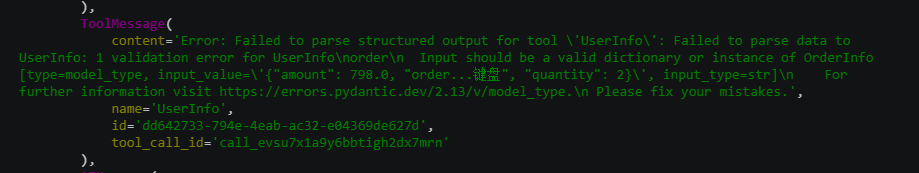

关键信息：
报错字段：order
期望类型：OrderInfo 对象或 dict
实际传入：字符串 '{"amount": 798.0, ...}'
也就是说：模型把 order 字段的值序列化成了一个 JSON 字符串，而不是一个真正的对象/dict，Pydantic 校验时拒绝了。

## 方案1 给 OrderInfo 加 BeforeValidator，自动解析 JSON 字符串   
在 OrderInfo 上挂一个校验器：如果传进来的是字符串，先 json.loads 转成 dict 再校验。


In [14]:
import json
from typing import Any
from pydantic import BaseModel, Field, BeforeValidator
from typing import Annotated


def _parse_json_str(v: Any) -> Any:
    """如果传进来是 JSON 字符串，先解析成 dict"""
    if isinstance(v, str):
        try:
            return json.loads(v)
        except json.JSONDecodeError:
            return v
    return v


class OrderInfo(BaseModel):
    """订单信息"""
    order_no: str = Field(default="", description="订单号")
    product: str = Field(description="商品名称")
    quantity: int = Field(default=1, description="数量")
    amount: float = Field(default=0.0, description="金额（元）")
    priority: PriorityLevel = Field(default=PriorityLevel.MEDIUM, description="优先级")


# 用带 BeforeValidator 的类型包装
OrderInfoLoose = Annotated[OrderInfo, BeforeValidator(_parse_json_str)]


class UserInfo(BaseModel):
    """用户信息"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱")
    phone: str = Field(description="用户电话")
    order_no: str = Field(description="关联订单号")
    order: Optional[OrderInfoLoose] = Field(default=None, description="关联订单信息")
    
agent = create_agent(
    model=model,
    system_prompt=SystemMessage(content="" 
    "你是智能客服【小智】，专门回答用户关于个人账户的问题" 
    "当用户查询个人账户时" 
    "先查询用户名对应的账户信息是否存在" 
    "再依据账户下的订单号查询对应的账户信息" 
    "依据结果生成格式化用户信息对象"),
    response_format=ToolStrategy(schema=UserInfo),
    tools=[get_user_by_name,get_order_by_no]
)

response = agent.invoke({
    "messages": [
        (
            "我叫张三，我想知道我最近买了什么？"
        )
    ]
})

rprint(response)
    

{
    'messages': [
        HumanMessage(
            content='我叫张三，我想知道我最近买了什么？',
            additional_kwargs={},
            response_metadata={},
            id='d687626e-ff96-447c-b3a2-dba6b0c30625'
        ),
        AIMessage(
            content='您好！我是智能客服小智，很高兴为您服务。让我先查询一下您的账户信息。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 104,
                    'prompt_tokens': 613,
                    'total_tokens': 717,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 70,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-5-3-flash-260828',
                'system_fingerprint': None,
                'id': '021790174667653e4d5e3acd6b6d5c09c835e2d36b9596c8933fe',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0ceb9-9d8c-7b33-9902-5dbd4a80ff32-0',
            tool_calls=[
                {
                    'name': 'get_user_by_name',
                    'args': {'name': '张三'},
                    'id': 'call_ts9ax7ichc6yning2oea3l52',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 613,
                'output_tokens': 104,
                'total_tokens': 717,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 70}
            }
        ),
        ToolMessage(
            content="name='张三' email='zhangsan@example.com' phone='138-0000-1234' order_no='ORD-2024-88888' 
order=None",
            name='get_user_by_name',
            id='b073dffd-9afd-40be-bec2-e0f5d99f32a7',
            tool_call_id='call_ts9ax7ichc6yning2oea3l52'
        ),
        AIMessage(
            content='已找到您的账户信息，现在为您查询关联订单的详细信息。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 64,
                    'prompt_tokens': 688,
                    'total_tokens': 752,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 30,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-5-3-flash-260828',
                'system_fingerprint': None,
                'id': '021790174670314e4d5e3acd6b6d5c09c835e2d36b9596c88b544',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0ceb9-a82f-73b3-a760-59887fe09269-0',
            tool_calls=[
                {
                    'name': 'get_order_by_no',
                    'arg

In [15]:
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

我叫张三，我想知道我最近买了什么？
================================== Ai Message ==================================

您好！我是智能客服小智，很高兴为您服务。让我先查询一下您的账户信息。
Tool Calls:
  get_user_by_name (call_ts9ax7ichc6yning2oea3l52)
 Call ID: call_ts9ax7ichc6yning2oea3l52
  Args:
    name: 张三
================================= Tool Message =================================
Name: get_user_by_name

name='张三' email='zhangsan@example.com' phone='138-0000-1234' order_no='ORD-2024-88888' order=None
================================== Ai Message ==================================

已找到您的账户信息，现在为您查询关联订单的详细信息。
Tool Calls:
  get_order_by_no (call_5du26g9vbzstbmadefu1cqaa)
 Call ID: call_5du26g9vbzstbmadefu1cqaa
  Args:
    order_no: ORD-2024-88888
================================= Tool Message =================================
Name: get_order_by_no

order_no='ORD-2024-88888' product='机械键盘' quantity=2 amount=798.0 priority=<PriorityLevel.HIGH: 'high'>
=

正常输出，不再报错

方法2，修改数据类型改为dict字典

方法3，取消嵌套，直接让模型额外输出订单信息

## TypeDict 类型

In [19]:
import os
from typing import TypedDict
from dotenv import load_dotenv
from langchain_core.tools import tool

from langchain.agents.structured_output import AutoStrategy,ToolStrategy 
from langchain_core.messages import SystemMessage
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from rich import print as rprint

load_dotenv(override=True)
ARK_API_KEY = os.getenv("ARK_API_KEY")
ARK_MODEL_NAME = os.getenv("ARK_MODEL_NAME")
ARK_BASE_URL = os.getenv("ARK_BASE_URL")
model = ChatOpenAI(
    model= ARK_MODEL_NAME,
    api_key= ARK_API_KEY,
    base_url= ARK_BASE_URL
)
#typedict

class ContractInfo(TypedDict):
    '''用户联系方式'''
    name : Annotated[str,...,"用户姓名"]
    email : Annotated[str,...,"用户邮箱"]
    phone : Annotated[str,...,"用户电话"]


agent = create_agent(
    model = model, 
    response_format= ToolStrategy(schema=ContractInfo)
)

#调用
response = agent.invoke({
    "messages": [
        "请以客服『张三』的身份回复我，邮箱 zhangsan@example.com，电话 138-0000-1234"
    ]
})

rprint(response)


{
    'messages': [
        HumanMessage(
            content='请以客服『张三』的身份回复我，邮箱 zhangsan@example.com，电话 138-0000-1234',
            additional_kwargs={},
            response_metadata={},
            id='f61e749e-9d71-4bb5-b252-ec9d31fd68d6'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 142,
                    'prompt_tokens': 201,
                    'total_tokens': 343,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 108,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-5-3-flash-260828',
                'system_fingerprint': None,
                'id': '021790175403125f0b662e0a22462bcc30964e8c71cc7661bd497',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0cec4-d674-79e1-94c9-c55b193bf8bc-0',
            tool_calls=[
                {
                    'name': 'ContractInfo',
                    'args': {'email': 'zhangsan@example.com', 'name': '张三', 'phone': '138-0000-1234'},
                    'id': 'call_92rfluizka23486rqwivpqcn',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 201,
                'output_tokens': 142,
                'total_tokens': 343,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 108}
            }
        ),
        ToolMessage(
            content="Returning structured response: {'name': '张三', 'email': 'zhangsan@example.com', 'phone': 
'138-0000-1234'}",
            name='ContractInfo',
            id='0dd0822a-41a9-4496-bd66-66088d2a1bff',
            tool_call_id='call_92rfluizka23486rqwivpqcn'
        )
    ],
    'structured_response': {'name': '张三', 'email': 'zhangsan@example.com', 'phone': '138-0000-1234'}
}

In [17]:
rprint(type(response))

<class 'dict'>

## JsonSchema 格式

In [20]:
import os

from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain_openai import ChatOpenAI
from rich import print as rprint

load_dotenv(override=True)
ARK_API_KEY = os.getenv("ARK_API_KEY")
ARK_MODEL_NAME = os.getenv("ARK_MODEL_NAME")
ARK_BASE_URL = os.getenv("ARK_BASE_URL")

model = ChatOpenAI(
    model=ARK_MODEL_NAME,
    api_key=ARK_API_KEY,
    base_url=ARK_BASE_URL,
)


# ============ JSON Schema 定义 ============
CONTRACT_INFO_SCHEMA = {
    "title": "ContractInfo",
    "description": "用户联系方式",
    "type": "object",
    "properties": {
        "name": {
            "type": "string",
            "description": "用户姓名",
        },
        "email": {
            "type": "string",
            "description": "用户邮箱",
        },
        "phone": {
            "type": "string",
            "description": "用户电话",
        },
    },
    "required": ["name", "email", "phone"],
}


agent = create_agent(
    model=model,
    response_format=ToolStrategy(schema=CONTRACT_INFO_SCHEMA),
)

# 调用
response = agent.invoke({
    "messages": [
        "请以客服『张三』的身份回复我，邮箱 zhangsan@example.com，电话 138-0000-1234"
    ]
})

rprint(response)

{
    'messages': [
        HumanMessage(
            content='请以客服『张三』的身份回复我，邮箱 zhangsan@example.com，电话 138-0000-1234',
            additional_kwargs={},
            response_metadata={},
            id='f01ab7bc-f8cb-4472-a385-d903e3cdb030'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 474,
                    'prompt_tokens': 223,
                    'total_tokens': 697,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 440,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-5-3-flash-260828',
                'system_fingerprint': None,
                'id': '0217901754452343d3436761e68cde6bd2815b0b11060ac68c7d4',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0cec5-7af3-79e1-8b2b-aa17bebc1ff9-0',
            tool_calls=[
                {
                    'name': 'ContractInfo',
                    'args': {'email': 'zhangsan@example.com', 'name': '张三', 'phone': '138-0000-1234'},
                    'id': 'call_0jcym7ujyotoz2stzco4c20x',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 223,
                'output_tokens': 474,
                'total_tokens': 697,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 440}
            }
        ),
        ToolMessage(
            content="Returning structured response: {'email': 'zhangsan@example.com', 'name': '张三', 'phone': 
'138-0000-1234'}",
            name='ContractInfo',
            id='66bfafc6-04cd-48c7-ac3c-4bd24afe31b3',
            tool_call_id='call_0jcym7ujyotoz2stzco4c20x'
        )
    ],
    'structured_response': {'email': 'zhangsan@example.com', 'name': '张三', 'phone': '138-0000-1234'}
}

In [21]:
print(type(response))

<class 'dict'>


In [23]:
# ============ dataclass 定义 ============
from dataclasses import dataclass, field


@dataclass
class ContractInfo:
    """用户联系方式"""
    name: str = field(metadata={"description": "用户姓名"})
    email: str = field(metadata={"description": "用户邮箱"})
    phone: str = field(metadata={"description": "用户电话"})


agent = create_agent(
    model=model,
    response_format=ToolStrategy(schema=ContractInfo),
)

# 调用
response = agent.invoke({
    "messages": [
        "请以客服『张三』的身份回复我，邮箱 zhangsan@example.com，电话 138-0000-1234"
    ]
})

rprint(response)
rprint(type(response["structured_response"]))

{
    'messages': [
        HumanMessage(
            content='请以客服『张三』的身份回复我，邮箱 zhangsan@example.com，电话 138-0000-1234',
            additional_kwargs={},
            response_metadata={},
            id='00ed6f8e-b29e-4d59-b26a-50adbf9eff6d'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 171,
                    'prompt_tokens': 222,
                    'total_tokens': 393,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 137,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-5-3-flash-260828',
                'system_fingerprint': None,
                'id': '021790175823160e4d5e3acd6b6d5c09c835e2d36b9596cced9ba',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0cecb-3f47-7443-bb88-1f96581029bb-0',
            tool_calls=[
                {
                    'name': 'ContractInfo',
                    'args': {'email': 'zhangsan@example.com', 'name': '张三', 'phone': '138-0000-1234'},
                    'id': 'call_xkvx2yimoh4l1nxeuo2i78sn',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 222,
                'output_tokens': 171,
                'total_tokens': 393,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 137}
            }
        ),
        ToolMessage(
            content="Returning structured response: ContractInfo(name='张三', email='zhangsan@example.com', 
phone='138-0000-1234')",
            name='ContractInfo',
            id='f7324bef-ee8f-4589-86af-13d0430389dd',
            tool_call_id='call_xkvx2yimoh4l1nxeuo2i78sn'
        )
    ],
    'structured_response': ContractInfo(name='张三', email='zhangsan@example.com', phone='138-0000-1234')
}

<class '__main__.ContractInfo'>

## 多schema联合模式

In [24]:
from typing import Literal

from langchain_protocol import Union
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# 定义第一个 Schema：产品评论
class ProductReview(BaseModel):
    """关于产品的评论"""
    rating: int | None = Field(description="产品评分 (1-5)")
    sentiment: Literal["positive", "negative"] = Field(description="评论情感")
    key_points: list[str] = Field(description="评论要点")

# 定义第二个 Schema：客户投诉
class CustomerComplaint(BaseModel):
    """关于产品或服务的客户投诉"""
    issue_type: Literal["product", "service", "shipping", "billing"] = Field(description="问题类型")
    severity: Literal["low", "medium", "high"] = Field(description="严重程度")
    description: str = Field(description="投诉简述")

# 使用 Union 组合多个 Schema
agent = create_agent(
    model=model,  # 示例模型
    response_format=ToolStrategy(schema= Union[ProductReview, CustomerComplaint])
)

# 调用时，模型会自动判断该用哪个 Schema
result = agent.invoke({
    "messages": [{"role": "user", "content": "分析这条评论：'孩子很喜欢，很好用，但有点贵'"}]
})

In [26]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

分析这条评论：'孩子很喜欢，很好用，但有点贵'
================================== Ai Message ==================================

我来分析这条评论。这是一条关于产品的用户评论，整体情感偏向正面，但包含一个价格方面的轻微抱怨。
Tool Calls:
  ProductReview (call_34at7bddb6jp8p4sodq4i9zb)
 Call ID: call_34at7bddb6jp8p4sodq4i9zb
  Args:
    key_points: ['孩子很喜欢该产品', '产品很好用', '价格偏贵']
    rating: 4
    sentiment: positive
================================= Tool Message =================================
Name: ProductReview

Returning structured response: rating=4 sentiment='positive' key_points=['孩子很喜欢该产品', '产品很好用', '价格偏贵']


试试让模型调用另外一种格式

In [ ]:
result = agent.invoke({
    "messages": ["分析这条评论：'货不对板，商家已读不回'"]
})

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

分析这条评论：'货不对板，商家已读不回'
================================== Ai Message ==================================

我来分析这条评论。这是一条明显的负面评论，包含两个核心问题：**商品与描述不符**（货不对板）和**商家售后不响应**（已读不回）。我将同时记录产品评论和相应的客户投诉：
Tool Calls:
  ProductReview (call_sm7trkqett184kavbyqnru1k)
 Call ID: call_sm7trkqett184kavbyqnru1k
  Args:
    key_points: ['货不对板，商品与描述不符', '商家已读不回，售后无响应']
    rating: 1
    sentiment: negative
  CustomerComplaint (call_tkpnc4y83t6ct2a826cdnv7g)
 Call ID: call_tkpnc4y83t6ct2a826cdnv7g
  Args:
    description: 客户反映商品与描述不符（货不对板），实际收到的产品与页面宣传不一致
    issue_type: product
    severity: high
  CustomerComplaint (call_780zuv50xnbrll8xphws8hu1)
 Call ID: call_780zuv50xnbrll8xphws8hu1
  Args:
    description: 客户反映商家已读不回，对客户的售后咨询/投诉没有任何回应，服务态度恶劣
    issue_type: service
    severity: high
================================= Tool Message =================================
Name: ProductReview

Error: Model incorrectly returned multiple

注意到，大模型调用了多个tool方法

输入的评论太过模糊，既包含了产品描述、又包含了投诉，大模型想同时返回多个对象，但是框架限制了只能返回一个

ToolStrategy 多 Schema 模式的一个设计限制：一次只允许返回一个结构化响应，而模型想"全都记录"。

根本原因有三个，叠加在一起：

1. 多 Schema 模式下，模型理解成"多选项"而非"多选一"
它看到 Union[ProductReview, CustomerComplaint]，误以为"这些都要填"，而不是"选一个填"。

2. 用户输入本身"横跨多个 Schema"
"货不对板，商家已读不回"

这句话同时符合评论和投诉，模型觉得两边都该记，于是都调了。

3. 模型把"结构化输出工具"当成了普通业务工具
普通工具（如 get_user_by_name）是可以一次调多个的（并行调用）。模型把同样的习惯带到了结构化输出工具上。

In [29]:
result = agent.invoke({
    "messages": ["分析这条评论：'商家已读不回'"]
})

for message in result["messages"]:
    message.pretty_print()
rprint(result["structured_response"])

================================ Human Message =================================

分析这条评论：'商家已读不回'
================================== Ai Message ==================================

这条评论"商家已读不回"反映的是客户对商家服务态度的不满，属于服务类投诉而非产品评价。让我进行结构化分析：
Tool Calls:
  CustomerComplaint (call_fgntunfro7nsikc8f92yjz0c)
 Call ID: call_fgntunfro7nsikc8f92yjz0c
  Args:
    description: 客户反馈商家已读消息但不回复，反映出商家客服响应缺失、服务态度消极，客户沟通诉求被忽视。
    issue_type: service
    severity: medium
================================= Tool Message =================================
Name: CustomerComplaint

Returning structured response: issue_type='service' severity='medium' description='客户反馈商家已读消息但不回复，反映出商家客服响应缺失、服务态度消极，客户沟通诉求被忽视。'


CustomerComplaint(
    issue_type='service',
    severity='medium',
    description='客户反馈商家已读消息但不回复，反映出商家客服响应缺失、服务态度消极，客户沟通诉求被忽视。'
)

## 自定义工具消息 tool_message_content

In [6]:
import os
from dotenv import load_dotenv
from langchain_core.tools import tool

from langchain.agents.structured_output import AutoStrategy,ToolStrategy 
from langchain_core.messages import SystemMessage
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from rich import print as rprint

from dotenv import load_dotenv
from langchain_protocol import Union
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

load_dotenv(override=True)
ARK_API_KEY = os.getenv("ARK_API_KEY")
ARK_MODEL_NAME = os.getenv("ARK_MODEL_NAME")
ARK_BASE_URL = os.getenv("ARK_BASE_URL")
model = ChatOpenAI(
    model= ARK_MODEL_NAME,
    api_key= ARK_API_KEY,
    base_url= ARK_BASE_URL
)

# 定义第一个 Schema：产品评论
class ProductReview(BaseModel):
    """关于产品的评论"""
    rating: int | None = Field(description="产品评分 (1-5)")
    sentiment: Literal["positive", "negative"] = Field(description="评论情感")
    key_points: list[str] = Field(description="评论要点")

# 定义第二个 Schema：客户投诉
class CustomerComplaint(BaseModel):
    """关于产品或服务的客户投诉"""
    issue_type: Literal["product", "service", "shipping", "billing"] = Field(description="问题类型")
    severity: Literal["low", "medium", "high"] = Field(description="严重程度")
    description: str = Field(description="投诉简述")

# 使用 Union 组合多个 Schema
agent = create_agent(
    model=model,  # 示例模型
    response_format=ToolStrategy(schema= Union[ProductReview, CustomerComplaint])
)

# 调用时，模型会自动判断该用哪个 Schema
result = agent.invoke({
    "messages": ["分析这条评论：'好用，爱用，还会再次复购'"]
})

for message in result["messages"]:
    message.pretty_print()
rprint(result["structured_response"])

================================ Human Message =================================

分析这条评论：'好用，爱用，还会再次复购'
================================== Ai Message ==================================

我来分析这条评论。这是一条明显的正面评价，包含产品使用体验和复购意愿的表述。
Tool Calls:
  ProductReview (call_i6ajmmfrnxm161fbk4xtrqgn)
 Call ID: call_i6ajmmfrnxm161fbk4xtrqgn
  Args:
    key_points: ['产品好用，使用体验良好', '用户喜欢使用该产品', '有明确的再次复购意愿，表明高度满意']
    rating: 5
    sentiment: positive
================================= Tool Message =================================
Name: ProductReview

Returning structured response: rating=5 sentiment='positive' key_points=['产品好用，使用体验良好', '用户喜欢使用该产品', '有明确的再次复购意愿，表明高度满意']


ProductReview(
    rating=5,
    sentiment='positive',
    key_points=['产品好用，使用体验良好', '用户喜欢使用该产品', '有明确的再次复购意愿，表明高度满意']
)

In [8]:
rprint(result)

{
    'messages': [
        HumanMessage(
            content="分析这条评论：'好用，爱用，还会再次复购'",
            additional_kwargs={},
            response_metadata={},
            id='42af635e-fe17-486e-bea3-5ace0239eaca'
        ),
        AIMessage(
            content='我来分析这条评论。这是一条明显的正面评价，包含产品使用体验和复购意愿的表述。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 202,
                    'prompt_tokens': 371,
                    'total_tokens': 573,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 129,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-5-3-flash-260828',
                'system_fingerprint': None,
                'id': '021790177251629fa871229fec4115dc08043e38393b8b550f399',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0cee1-0b42-72c2-9ed5-f5040c4c8f97-0',
            tool_calls=[
                {
                    'name': 'ProductReview',
                    'args': {
                        'key_points': [
                            '产品好用，使用体验良好',
                            '用户喜欢使用该产品',
                            '有明确的再次复购意愿，表明高度满意'
                        ],
                        'rating': '5',
                        'sentiment': 'positive'
                    },
                    'id': 'call_i6ajmmfrnxm161fbk4xtrqgn',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 371,
                'output_tokens': 202,
                'total_tokens': 573,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 129}
            }
        ),
        ToolMessage(
            content="Returning structured response: rating=5 sentiment='positive' 
key_points=['产品好用，使用体验良好', '用户喜欢使用该产品', '有明确的再次复购意愿，表明高度满意']",
            name='ProductReview',
            id='bf66badb-8439-4e42-80e2-e5b3bc5f3712',
            tool_call_id='call_i6ajmmfrnxm161fbk4xtrqgn'
        )
    ],
    'structured_response': ProductReview(
        rating=5,
        sentiment='positive',
        key_points=['产品好用，使用体验良好', '用户喜欢使用该产品', '有明确的再次复购意愿，表明高度满意']
    )
}

In [9]:
# 简化toolMessage的内容
from langgraph.prebuilt import tools_condition


agent = create_agent(
    model=model,  # 示例模型
    response_format=ToolStrategy(
        schema= Union[ProductReview, CustomerComplaint],
        tool_message_content= "评价分析成功"
        ),
    
)
result = agent.invoke({
    "messages": ["分析这条评论：'好用，爱用，还会再次复购'"]
})

for message in result["messages"]:
    message.pretty_print()
rprint(result["structured_response"])

================================ Human Message =================================

分析这条评论：'好用，爱用，还会再次复购'
================================== Ai Message ==================================
Tool Calls:
  ProductReview (call_wzedp7b3xw1y51tr6ocpy0ri)
 Call ID: call_wzedp7b3xw1y51tr6ocpy0ri
  Args:
    key_points: ['产品好用', '用户喜欢使用', '有复购意愿，忠诚度高']
    rating: 5
    sentiment: positive
================================= Tool Message =================================
Name: ProductReview

评价分析成功


ProductReview(rating=5, sentiment='positive', key_points=['产品好用', '用户喜欢使用', '有复购意愿，忠诚度高'])

In [10]:
rprint(result)

{
    'messages': [
        HumanMessage(
            content="分析这条评论：'好用，爱用，还会再次复购'",
            additional_kwargs={},
            response_metadata={},
            id='ae8ec428-72a5-45f2-89fa-448442241f79'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 148,
                    'prompt_tokens': 371,
                    'total_tokens': 519,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 106,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-5-3-flash-260828',
                'system_fingerprint': None,
                'id': '02179017747851939b5b0f4b57789945865e795386c3530cca119',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0cee4-818b-7f53-8e90-0850e00cb7f6-0',
            tool_calls=[
                {
                    'name': 'ProductReview',
                    'args': {
                        'key_points': ['产品好用', '用户喜欢使用', '有复购意愿，忠诚度高'],
                        'rating': '5',
                        'sentiment': 'positive'
                    },
                    'id': 'call_wzedp7b3xw1y51tr6ocpy0ri',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 371,
                'output_tokens': 148,
                'total_tokens': 519,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 106}
            }
        ),
        ToolMessage(
            content='评价分析成功',
            name='ProductReview',
            id='ecf86335-f2b4-46ce-b6a1-a2049d317217',
            tool_call_id='call_wzedp7b3xw1y51tr6ocpy0ri'
        )
    ],
    'structured_response': ProductReview(
        rating=5,
        sentiment='positive',
        key_points=['产品好用', '用户喜欢使用', '有复购意愿，忠诚度高']
    )
}